Accuracy : 0.9386
AUC-ROC : 0.9342


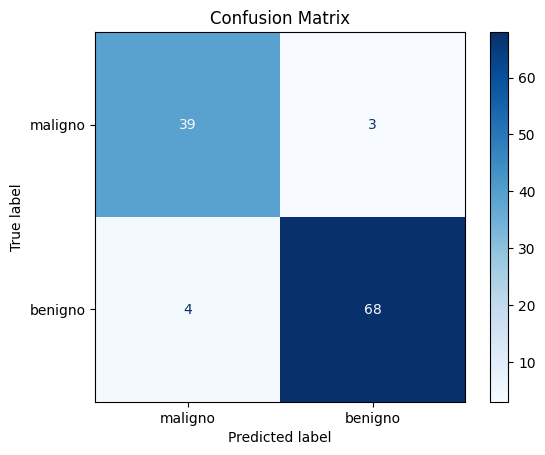

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

# Dati
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42, 
        stratify=y
)

# Modello
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Metriche
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
display_labels=['maligno','benigno']).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

# Carica il dataset
data = load_breast_cancer()
X = data.data # 569 campioni, 30 feature numeriche
y = data.target # 0 = maligno, 1 = benigno

# Stampa info
print(f"Dimensione dataset: {X.shape}")
print(f"Classi: {data.target_names}") # ['malignant' 'benign']
print(f"Distribuzione classi: {pd.Series(y).value_counts().to_dict()}")

# Split train/test: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42, # riproducibilità
stratify=y # mantiene la proporzione delle classi
)
print(f"Train: {X_train.shape[0]} campioni")
print(f"Test: {X_test.shape[0]} campioni")

Dimensione dataset: (569, 30)
Classi: ['malignant' 'benign']
Distribuzione classi: {1: 357, 0: 212}
Train: 455 campioni
Test: 114 campioni


In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Crea il modello
# max_depth controlla la complessità → trade-off Bias-Varianza
dt = DecisionTreeClassifier(
        max_depth=2, # profondità massima dell'albero
        criterion='gini', # impurità di Gini (alternativa: 'entropy')
        min_samples_leaf=5, # almeno 5 campioni per foglia (regolarizzazione)
        random_state=42
)

# Addestramento
dt.fit(X_train, y_train)

# Predizione
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1] # probabilità della classe positiva (1 = benigno)
print("Prime 5 predizioni:", y_pred[:5])
print("Prime 5 probabilità:", y_proba[:5].round(3))
print(type(dt))
print(X_test.shape)
print(y_pred.shape)

Prime 5 predizioni: [0 1 0 0 0]
Prime 5 probabilità: [0.021 0.982 0.333 0.021 0.021]
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
(114, 30)
(114,)


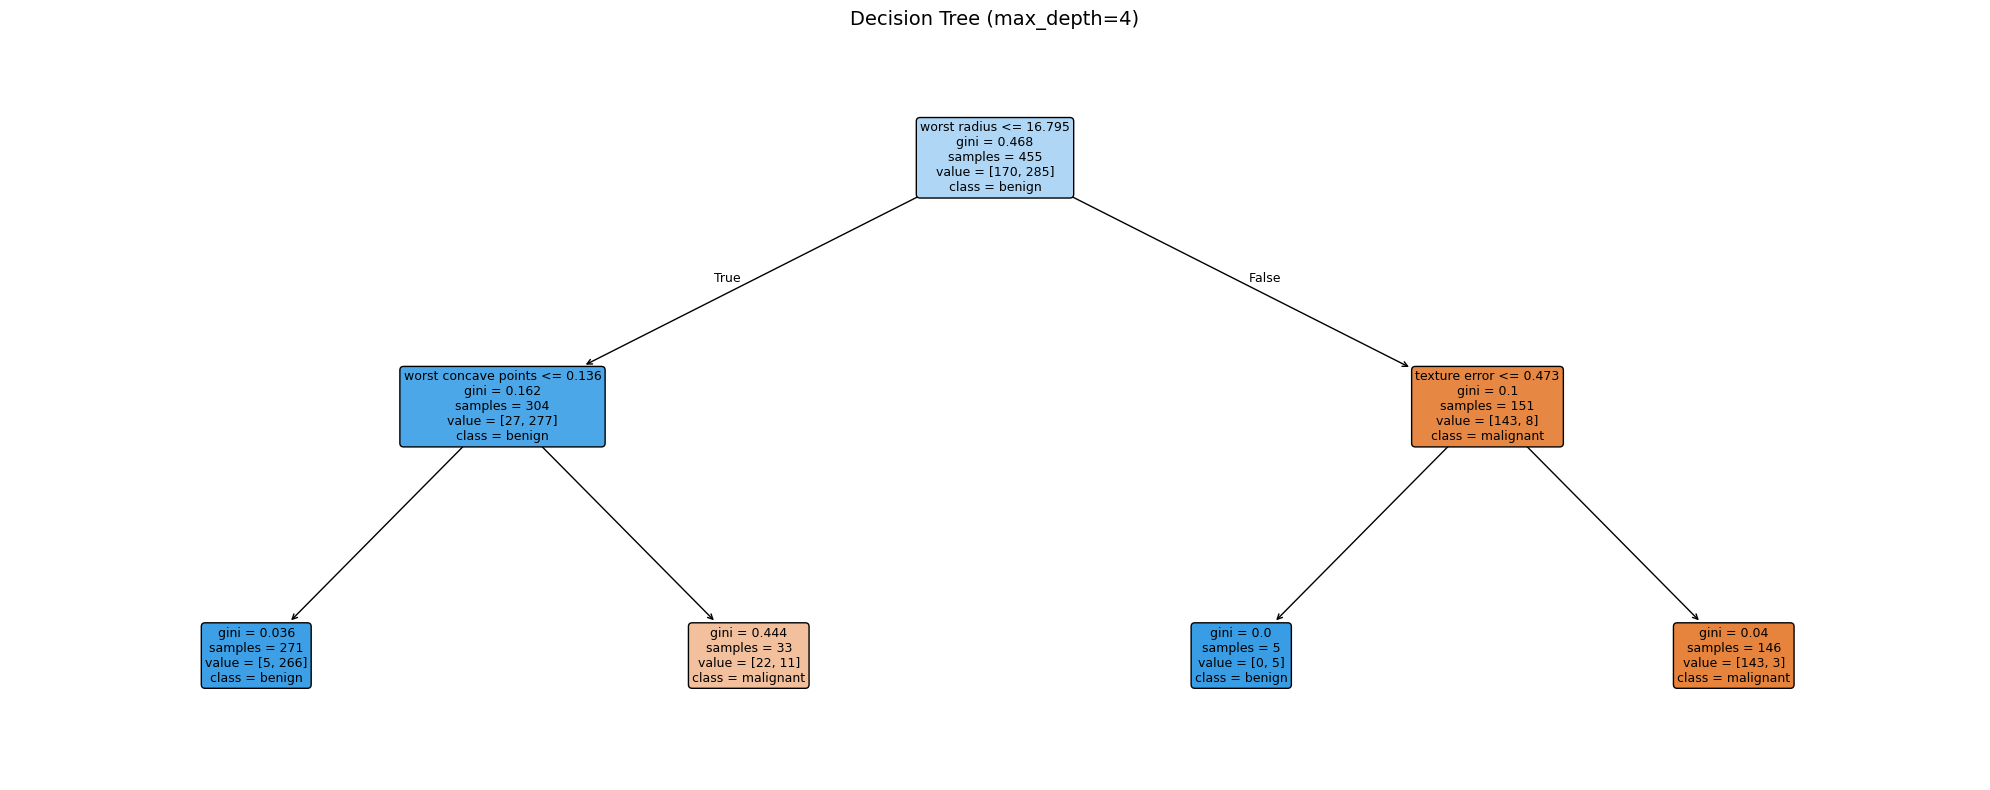

In [4]:
## Visualizzazione dell'Albero
plt.figure(figsize=(20, 8))
plot_tree(
dt,
feature_names=data.feature_names,
class_names=data.target_names,
filled=True, # colora i nodi per classe
rounded=True,
fontsize=9
)
plt.title("Decision Tree (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.show()


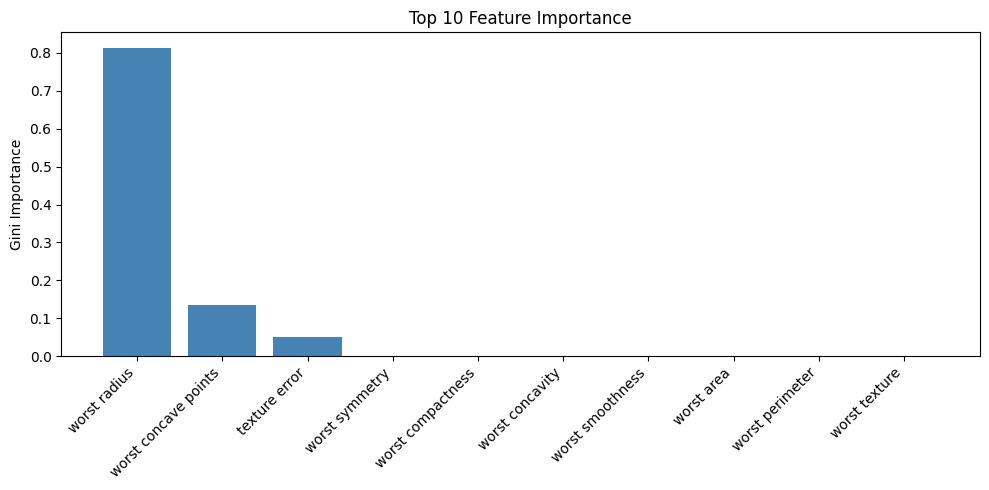

In [5]:
import numpy as np

importances = dt.feature_importances_
indices = np.argsort(importances)[::-1][:10] # top 10
plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices], color='steelblue')
plt.xticks(range(10), data.feature_names[indices], rotation=45, ha='right')
plt.title("Top 10 Feature Importance")
plt.ylabel("Gini Importance")
plt.tight_layout()
plt.show()

Accuracy: 0.8947 (89.47%)
Confusion Matrix:
 [[40  2]
 [10 62]]


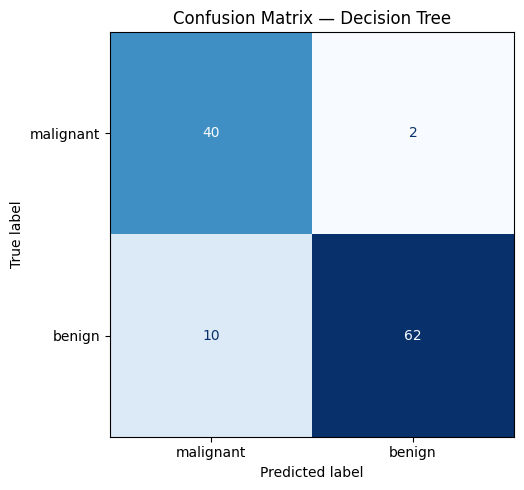


Classification Report:
              precision    recall  f1-score   support

   malignant       0.80      0.95      0.87        42
      benign       0.97      0.86      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.91      0.89       114
weighted avg       0.91      0.89      0.90       114



In [6]:
## Accuracy
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")

## Confusion Matrix
# Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualizzazione grafica
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()

# Report completo: precision, recall, f1 per ogni classe
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy : 0.9386
AUC-ROC : 0.9342


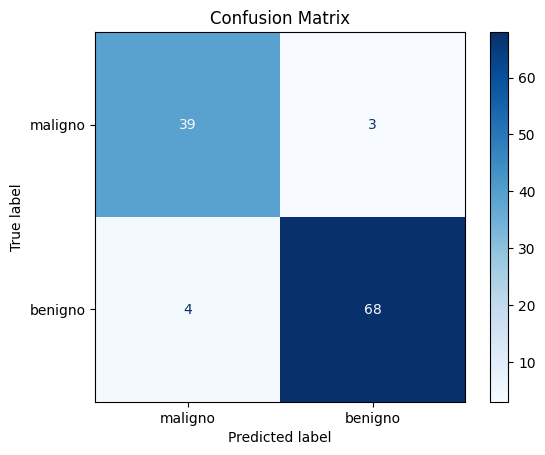

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

# Dati
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Modello
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Metriche
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
display_labels=['maligno','benigno']).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

AUC-ROC: 0.9342


Text(0.5, 0, 'False Positive Rate (FPR)')

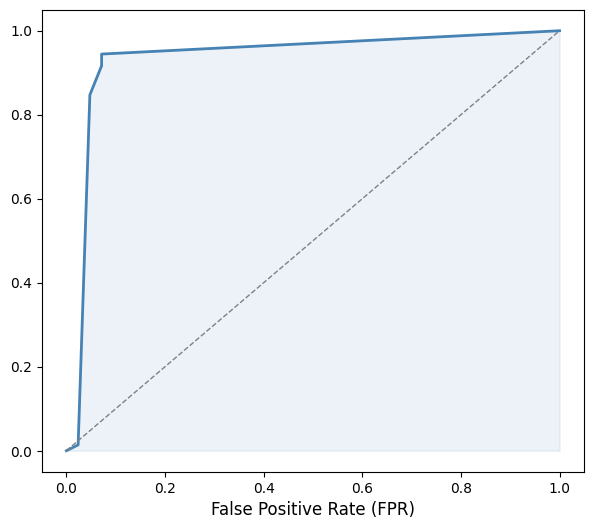

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# AUC score (richiede le probabilità, non le classi predette)
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}")

# Curva ROC completa
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Visualizzazione
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
label=f'Decision Tree (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1,
linestyle='--', label='Classificatore casuale (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue') # area sotto la curva
ax.set_xlabel("False Positive Rate (FPR)", fontsize=12)
